In [9]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from mech_interp_toolkit.activation_utils import concat_activations

In [15]:
collate_orig = []
collate_new = []

base = Path("dla_on_probes")
for f in base.glob("*.pt"):
    orig, new = torch.load(f, weights_only=False)
    orig.attention_mask = torch.empty(0)
    new.attention_mask = torch.empty(0)
    collate_orig.append(orig)
    collate_new.append(new)

In [16]:
orig = concat_activations(collate_orig)
new = concat_activations(collate_new)

In [17]:
type(collate_orig[0])

mech_interp_toolkit.activation_dict.ActivationDict

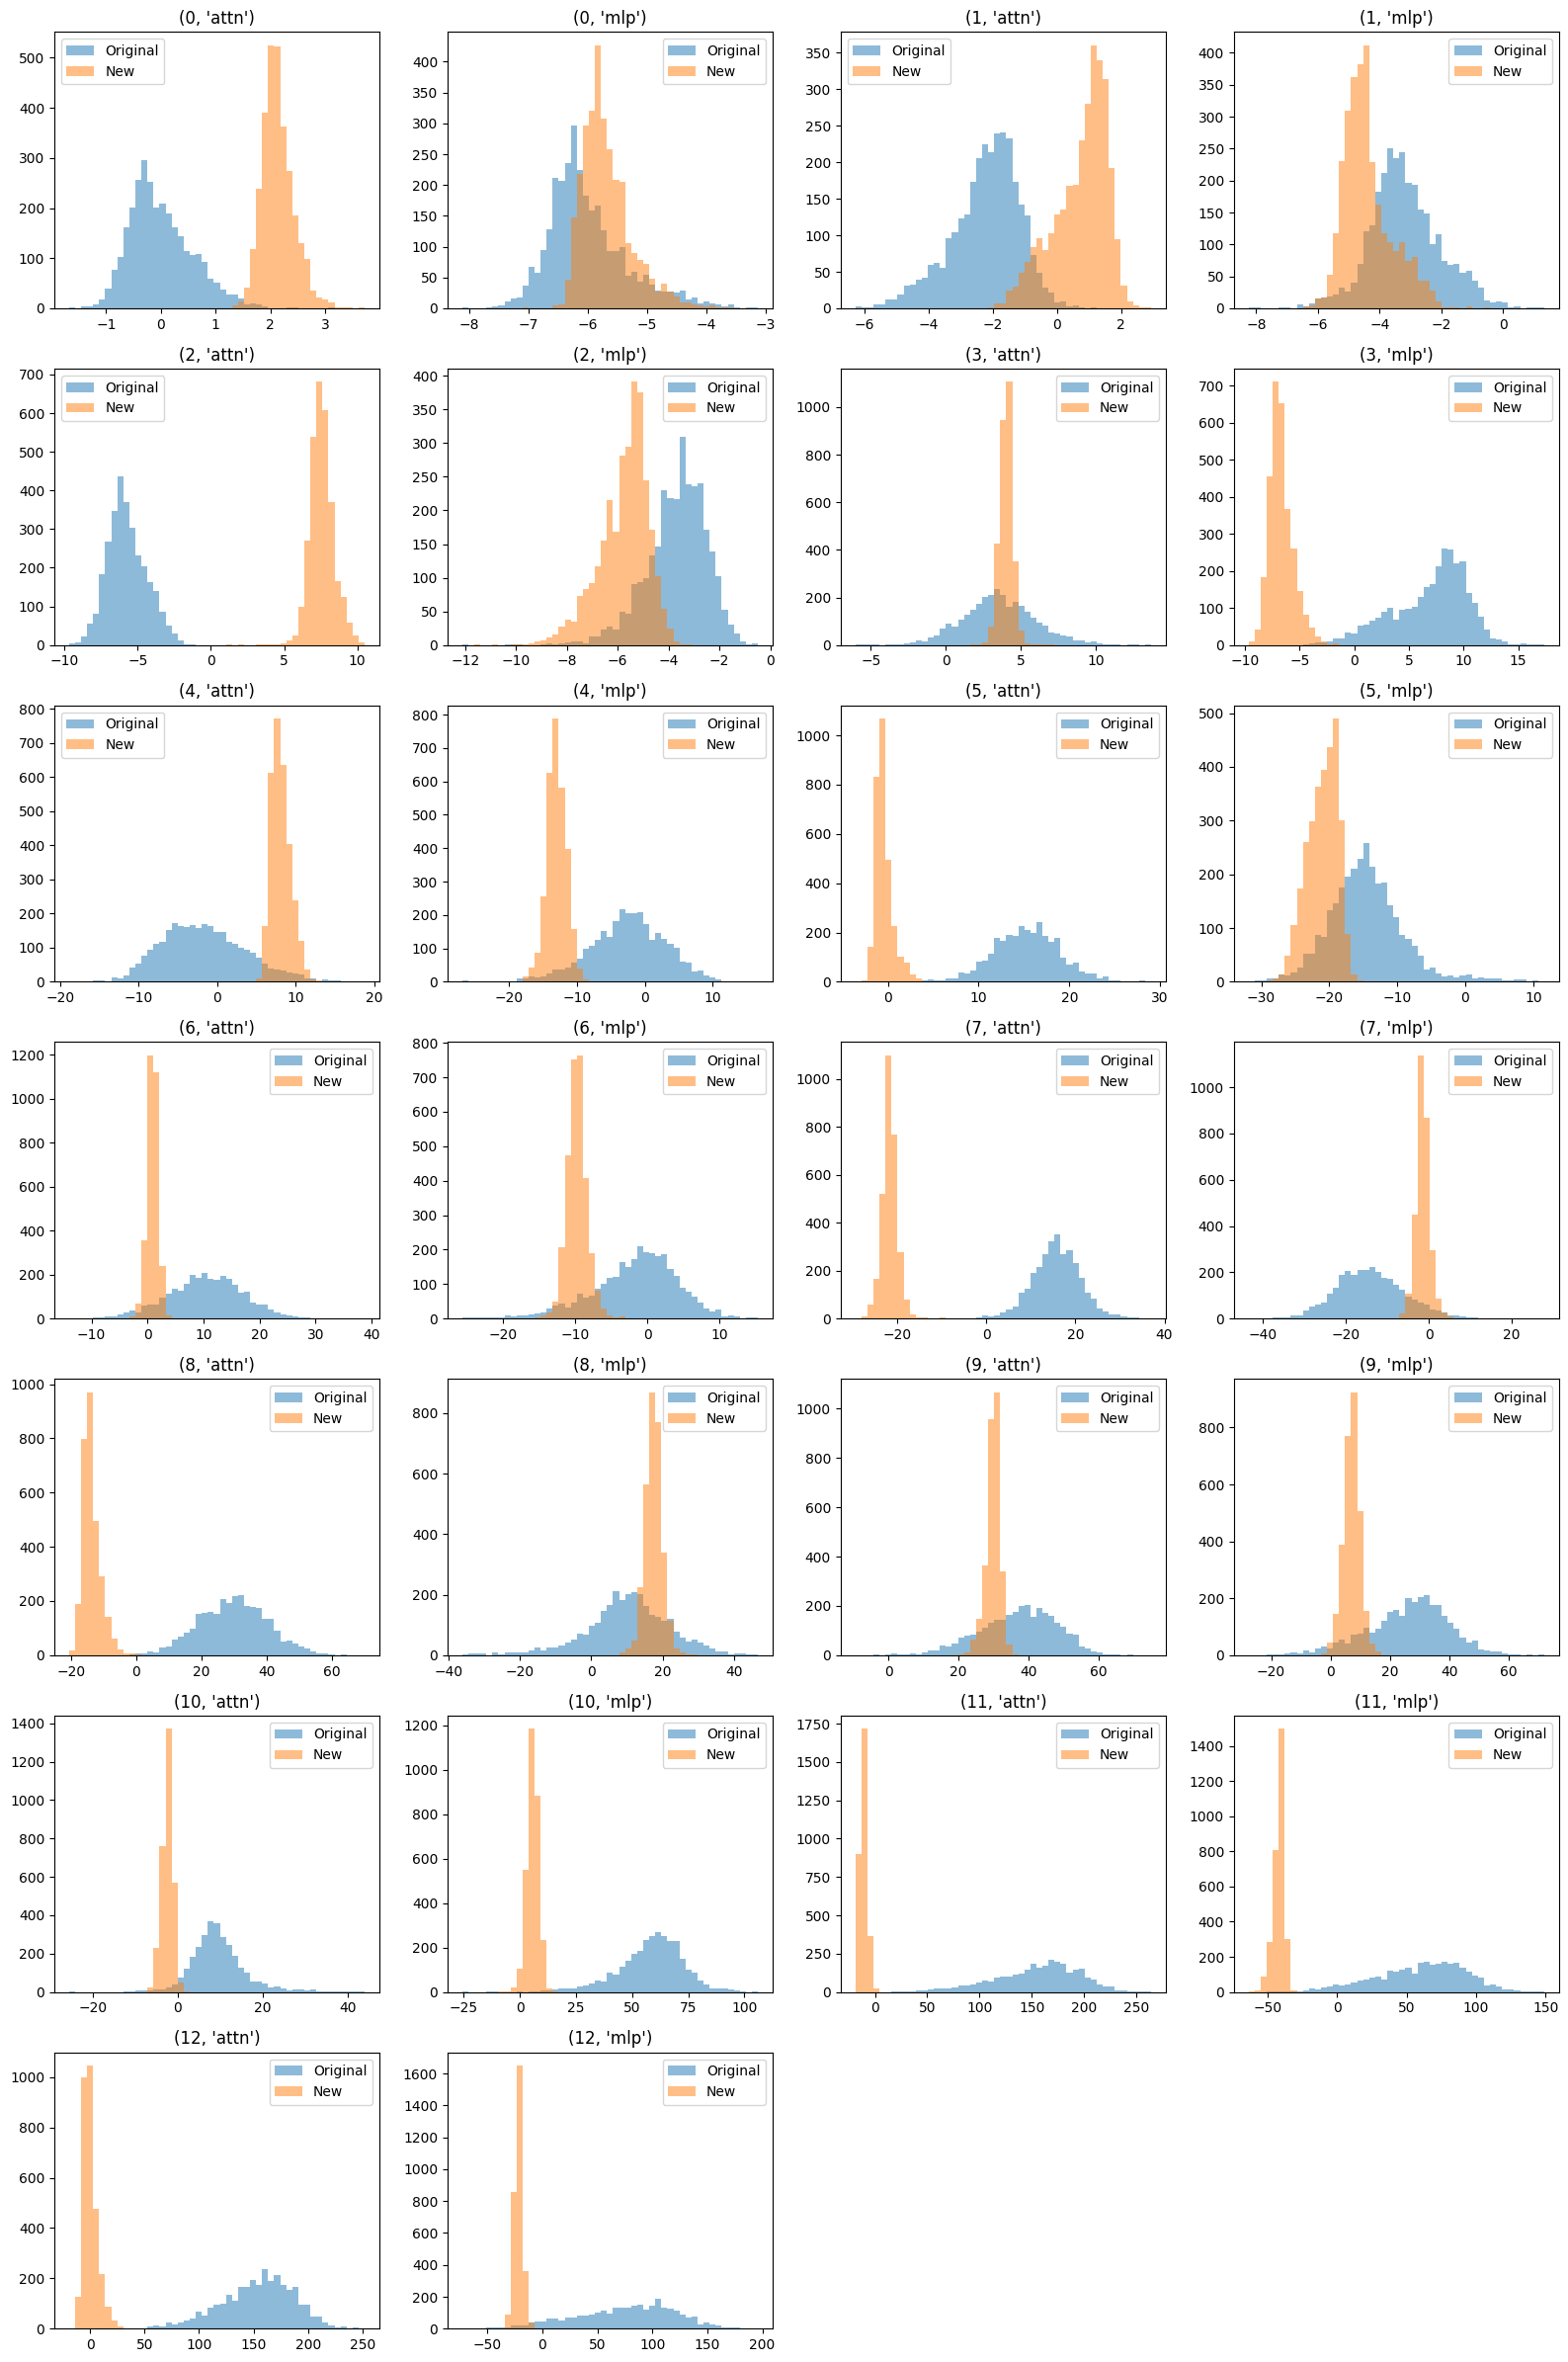

In [18]:
# Create a 7x4 grid of subplots
fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.flatten()

keys = list(orig.keys())

for idx, key in enumerate(keys):
    if idx >= 28:  # Only 28 subplots in a 7x4 grid
        break
    
    # Get data for both histograms
    data_orig = orig[key].float().numpy()
    data_new = new[key].float().numpy()
    
    # Determine shared bins based on combined data range
    all_data = torch.cat([orig[key].float(), new[key].float()])
    min_val, max_val = all_data.min().item(), all_data.max().item()
    bins = torch.linspace(min_val, max_val, 50)
    
    # Plot both histograms with the same bins
    axes[idx].hist(data_orig, bins=bins.numpy(), alpha=0.5, label='Original')
    axes[idx].hist(data_new, bins=bins.numpy(), alpha=0.5, label='New')
    axes[idx].set_title(key)
    axes[idx].legend()

# Hide any unused subplots
for idx in range(len(keys), 28):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()